In [3]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

path = "/home/students/studweilc1/MU-Diff/"
# add this to path for imports
if path not in sys.path:
    sys.path.append(path)

In [4]:
import numpy as np
import os 
# import pillow
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
org_data = np.load("../data/my_data2/test/DIXON.npy")

In [29]:

def transform_png_to_npy(save_folder, path_to_folder = "../predictions/exp_brats2", split="test"):

    files = os.listdir(os.path.join(path_to_folder, split, "synthetic"))
    files = [f for f in files if f.endswith(".png")]
    files = sorted(files)

    # load all files and stack ans npy arary
    all_data = []
    for f in files:
        img_path = os.path.join(path_to_folder, split, "synthetic", f)
        # load png file as np arry
        img = Image.open(img_path)
        # convert to 0-1
        img = np.array(img) / 255.0
        img = np.transpose(img, (1, 0))
        all_data.append(img)
    all_data = np.stack(all_data, axis=0)
    save_folder = os.path.join(save_folder, split)
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    np.save(os.path.join(save_folder, "synthetic.npy"), all_data)

transform_png_to_npy(path_to_folder = "../predictions/exp_brats2", split="test", save_folder="../data/synthetic/exp_brats2")
transform_png_to_npy(path_to_folder = "../predictions/exp_brats2", split="train", save_folder="../data/synthetic/exp_brats2")
transform_png_to_npy(path_to_folder = "../predictions/exp_brats2", split="val", save_folder="../data/synthetic/exp_brats2")

## Test Loaders

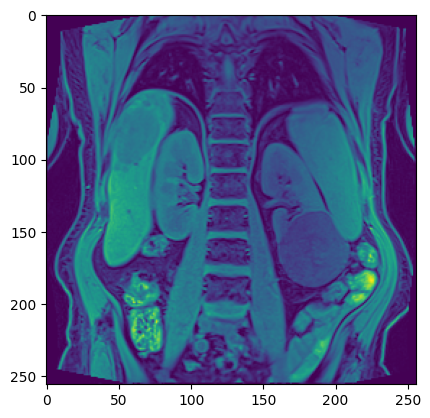

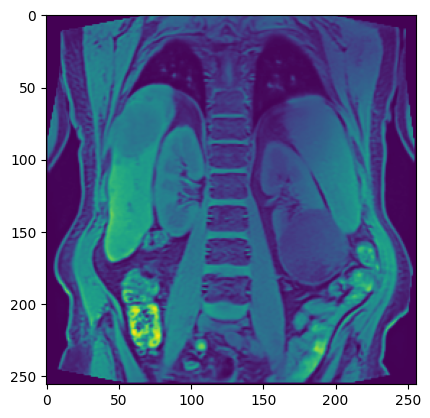

In [30]:
org_data = np.load("../data/my_data2/test/DIXON.npy")
plt.imshow(org_data[10,:,:])
plt.show()

org_data = np.load("../data/synthetic/exp_brats2/test/synthetic.npy")
tmp = org_data[10,:,:]
plt.imshow(tmp)
plt.show()